****Seq_to_Seq LSTM****


**Mobility_and_Mortality**


Data PrePrpcessing


In [1]:

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

                                                                                                         
path = "Merged_1.csv"
df = pd.read_csv(path)

df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')
df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'stringency_index': 'Stringency Index',
    'population': 'Population',
    'retail_and_recreation_percent_change_from_baseline': 'Retail and Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery and Pharmacy',
    'parks_percent_change_from_baseline': 'Parks',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)
df['time_step'] = df.groupby('Country').cumcount()

time_series_features = [
    'Retail and Recreation','Grocery and Pharmacy',
    'Parks','Transit Stations','Workplaces','Residential'
]

                                                                                                              
for col in time_series_features:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.interpolate().ffill().bfill())
    df[col] = df.groupby('Country')[col].transform(lambda x: StandardScaler().fit_transform(x.values.reshape(-1,1)).ravel())

                                                                                                     
df['TotalDeaths'] = df['TotalDeaths'].fillna(0)
daily = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = daily.groupby(df['Country']).cumsum()
df['cumulative_norm'] = df.groupby('Country')['CumulativeDeaths'].transform(
    lambda x: x / (x.max() if x.max() > 0 else 1.0)
)


Detaset Class (EnD and DEC)

In [2]:

class Seq2SeqDataset(Dataset):
    def __init__(self, df, enc_len=100, dec_len=30):
        self.enc_len = enc_len
        self.dec_len = dec_len
        self.groups = []
        self.time_cols = time_series_features
        self.target_col = 'cumulative_norm'
        
        for country, g in df.groupby('Country'):
            g = g.sort_values('time_step')
            if len(g) >= enc_len + dec_len:
                self.groups.append((country, g.reset_index(drop=True)))

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        country, g = self.groups[idx]
        x_time = g[self.time_cols].iloc[:self.enc_len].values.astype(np.float32)
        y_full = g[self.target_col].iloc[:self.enc_len+self.dec_len].values.astype(np.float32)
        return torch.tensor(x_time), torch.tensor(y_full), country



Model (Full reconstruction + forecast)

In [3]:

import torch.nn as nn
import torch.nn.functional as F

class Seq2SeqLSTMFull(nn.Module):
    def __init__(self, input_dim_time, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = nn.LSTM(input_dim_time, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(1, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, enc_in, dec_in):
                                                                                                              
        _, (h, c) = self.encoder(enc_in)                                                                       
                                                                                                                
        dec_out, _ = self.decoder(dec_in, (h, c))                                                         
        out = self.fc(dec_out)                                                                            
        return F.softplus(out)                                                                             




Training Loop


In [4]:
def train_model_full(model, loader, epochs=500, lr=1e-2, clip=1.0, verbose_every=50):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_loss = float('inf')
    best_state = model.state_dict()
    
    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        for x_enc, y_full, _ in loader:
            opt.zero_grad()
            dec_in = y_full.unsqueeze(-1)                                                                    
            pred_full = model(x_enc, dec_in)                                                                 
            loss = loss_fn(pred_full.squeeze(-1), y_full)
            loss.backward()
            if clip:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total_loss += loss.item() * x_enc.size(0)
            
        epoch_loss = total_loss / len(loader.dataset)
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = model.state_dict()
        if ep % verbose_every == 0 or ep == 1 or ep == epochs:
            print(f"Epoch {ep}: Loss = {epoch_loss:.6f} (best {best_loss:.6f})")
    
    model.load_state_dict(best_state)
    print(f"\nBest training loss: {best_loss:.6f}")
    return model



Forecast Function (Train + Test + Full)

In [5]:
def forecast_seq2seq_full(model, df, country_name, enc_len=100, dec_len=30):
    g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)
    x_enc = g[time_series_features].iloc[:enc_len].values.astype(np.float32)
    y_full = g['cumulative_norm'].iloc[:enc_len+dec_len].values.astype(np.float32)
    
    x_enc_tensor = torch.tensor(x_enc).unsqueeze(0)                                                              
    dec_in_tensor = torch.tensor(y_full).unsqueeze(0).unsqueeze(-1)                                              
    
    with torch.no_grad():
        full_pred = model(x_enc_tensor, dec_in_tensor).squeeze(0).squeeze(-1).numpy()                                
    
    true_train = y_full[:enc_len]
    true_test  = y_full[enc_len:enc_len+dec_len]
    pred_train = full_pred[:enc_len]
    pred_test  = full_pred[enc_len:enc_len+dec_len]
    
    return true_train, true_test, pred_train, pred_test, y_full


In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""




Run Training + Forecasting

In [8]:
ENC_LEN = 100
DEC_LEN = 30
BATCH_SIZE = 78
EPOCHS = 2000
LR = 1e-2

dataset = Seq2SeqDataset(df, enc_len=ENC_LEN, dec_len=DEC_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = Seq2SeqLSTMFull(input_dim_time=len(time_series_features))
model = train_model_full(model, loader, epochs=EPOCHS, lr=LR, clip=1.0)

country_name = "Australia"
true_train, true_test, pred_train, pred_test, full_true = forecast_seq2seq_full(
    model, df, country_name, enc_len=ENC_LEN, dec_len=DEC_LEN
)



Epoch 1: Loss = 0.292053 (best 0.292053)
Epoch 50: Loss = 0.002319 (best 0.002049)
Epoch 100: Loss = 0.000478 (best 0.000474)
Epoch 150: Loss = 0.000247 (best 0.000247)
Epoch 200: Loss = 0.000182 (best 0.000182)
Epoch 250: Loss = 0.000160 (best 0.000157)
Epoch 300: Loss = 0.000143 (best 0.000129)
Epoch 350: Loss = 0.000122 (best 0.000117)
Epoch 400: Loss = 0.000154 (best 0.000117)
Epoch 450: Loss = 0.000119 (best 0.000114)
Epoch 500: Loss = 0.000103 (best 0.000103)
Epoch 550: Loss = 0.000098 (best 0.000094)
Epoch 600: Loss = 0.000093 (best 0.000087)
Epoch 650: Loss = 0.000085 (best 0.000081)
Epoch 700: Loss = 0.000085 (best 0.000079)
Epoch 750: Loss = 0.000083 (best 0.000073)
Epoch 800: Loss = 0.000075 (best 0.000073)
Epoch 850: Loss = 0.000067 (best 0.000067)
Epoch 900: Loss = 0.000074 (best 0.000065)
Epoch 950: Loss = 0.000082 (best 0.000059)
Epoch 1000: Loss = 0.000062 (best 0.000059)
Epoch 1050: Loss = 0.000061 (best 0.000054)
Epoch 1100: Loss = 0.000052 (best 0.000050)
Epoch 1150:

Plotting 

/tmp/ipykernel_1845848/3123736598.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16)


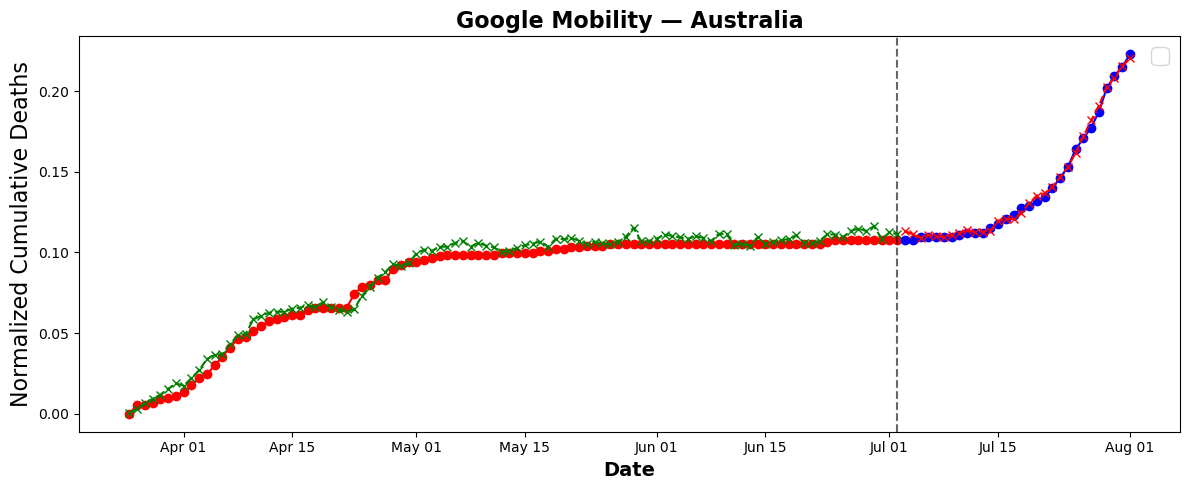

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)
g['Date'] = pd.to_datetime(g['Date'])

train_dates = g['Date'].iloc[:ENC_LEN].values
test_dates  = g['Date'].iloc[ENC_LEN:ENC_LEN+DEC_LEN].values

plt.figure(figsize=(12, 5))
plt.plot(train_dates, true_train, 'o-',  color='red')                                                
plt.plot(train_dates, pred_train, 'x--',color='green')                                                
plt.plot(test_dates, true_test, 'o-', color='blue')                                                   
plt.plot(test_dates, pred_test, 'x--', color='red')                                                  

                                                                                              
plt.axvline(train_dates[-1], color='k', linestyle='--', alpha=0.6, )
                                                                                               
plt.title(f'Google Mobility — {country_name}',fontsize=16 ,fontweight='bold')
plt.xlabel('Date', fontsize=14 ,fontweight='bold')
plt.ylabel('Normalized Cumulative Deaths', fontsize=16)                                                          
plt.legend(fontsize=16)
plt.grid(False)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
#ax.tick_params(axis='x', labelsize=16)
#ax.tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()


Save Prediction to CSV

In [16]:
"""
                                                                                         


country_name = "Australia"

                                                                                         
g = df[df['Country'] == country_name].sort_values('time_step').reset_index(drop=True)

                                                                                          
dates = g['Date'].iloc[:ENC_LEN + DEC_LEN].values

                                                                                          
out_df = pd.DataFrame({
    "Date": dates,
    "Country": country_name,
    "True_Cumulative_Normalized": np.concatenate([true_train, true_test]),
    "Predicted_Cumulative_Normalized": np.concatenate([pred_train, pred_test]),
    "Split": (["Train"] * ENC_LEN) + (["Forecast"] * DEC_LEN)
})

                                                                                               
filename = f"seq2seq_predictions_{country_name}.csv"
out_df.to_csv(filename, index=Fa                                                       

print(f"Saved file: {filename}")
"""

'\n                                                                                         \n\n\ncountry_name = "Australia"\n\n                                                                                         \ng = df[df[\'Country\'] == country_name].sort_values(\'time_step\').reset_index(drop=True)\n\n                                                                                          \ndates = g[\'Date\'].iloc[:ENC_LEN + DEC_LEN].values\n\n                                                                                          \nout_df = pd.DataFrame({\n    "Date": dates,\n    "Country": country_name,\n    "True_Cumulative_Normalized": np.concatenate([true_train, true_test]),\n    "Predicted_Cumulative_Normalized": np.concatenate([pred_train, pred_test]),\n    "Split": (["Train"] * ENC_LEN) + (["Forecast"] * DEC_LEN)\n})\n\n                                                                                               \nfilename = f"seq2seq_predictions_{country_name}.csv

Train and Test Error

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

                                                                                                                     
train_mse = mean_squared_error(true_train, pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(true_train, pred_train)

                                                                                                                    
test_mse = mean_squared_error(true_test, pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(true_test, pred_test)

print(f"Train MSE: {train_mse:.6f}, RMSE: {train_rmse:.6f}, MAE: {train_mae:.6f}")
print(f"Test  MSE: {test_mse:.6f}, RMSE: {test_rmse:.6f}, MAE: {test_mae:.6f}")

Train MSE: 0.000020, RMSE: 0.004490, MAE: 0.003798
Test  MSE: 0.000005, RMSE: 0.002214, MAE: 0.001735


In [16]:
# Combine dates
all_dates = np.concatenate([train_dates, test_dates])

# Combine true values
true_all = np.concatenate([true_train, true_test])

# Combine predictions
pred_all = np.concatenate([pred_train, pred_test])

# Split indicator
split = ["Train"]*len(true_train) + ["Forecast"]*len(true_test)

results_df = pd.DataFrame({
    "Date": all_dates,
    "True_Cumulative_Normalized": true_all,
    "Pred_Cumulative_Normalized": pred_all,
    "Split": split
})


In [17]:
results_df.to_csv(f"{country_name}_Seq2Seq_forecast.csv", index=False)

print("Saved:", f"{country_name}_Seq2Seq_forecast.csv")


Saved: Australia_Seq2Seq_forecast.csv


In [36]:
                                                                                                                     # Combine dates
dates = np.concatenate([train_dates, test_dates])

                                                                                                                     # Combine normalized values
true_norm = np.concatenate([true_train, true_test])
pred_norm = np.concatenate([pred_train, pred_test])

                                                                                                                      # Convert normalized → absolute deaths
max_deaths = g['CumulativeDeaths'].max()

true_abs = true_norm * max_deaths
pred_abs = pred_norm * max_deaths

                                                                                                                        # Split labels
split = ["Train"]*len(true_train) + ["Forecast"]*len(true_test)

                                                                                                                          # Build dataframe
results_df = pd.DataFrame({
    "Date": dates,
    "True_Cumulative_Normalized": true_norm,
    "Pred_Cumulative_Normalized": pred_norm,
    "True_Cumulative_Absolute": true_abs,
    "Pred_Cumulative_Absolute": pred_abs,
    "Split": split
})

                                                                                                                  # Format numbers (optional but good for papers)
results_df = results_df.round(6)

                                                                                                                    
results_df.to_csv(f"{country_name}_Seq2Seq_forecast.csv", index=False)

print("Saved:", f"{country_name}_Seq2Seq_forecast.csv")


Saved: Nigeria_Seq2Seq_forecast.csv
